# Ashwood-Style Mouse-Level Baseline Replication

This notebook follows the baseline GLM-HMM analysis from Ashwood et al. (2022),

**“Mice alternate between discrete strategies during perceptual decision-making”** 

([paper](https://doi.org/10.1038/s41593-021-01007-z)).

Main rule: **one GLM-HMM fit per mouse**, 

- use only the **1st 90** trials of each session, where left and right stimuli are **50/50(unbiased)** from many sessions.

- model inputs:
        stimulus contrast
        bias
        previous choice
        **win-stay / lose-switch** (previous choice * previous reward)

- 3-state значит, что модель ищет 3 скрытые стратегии у одной мыши.

fit a mouse-level 3-state GLM-HMM rather than one model per session, don't fit one model separately for each session.

- z-score the stimulus covariate

- compare GLM-HMM performance against simpler GLM baselines using session-level cross-validation


strict rule:
a mouse should have at least 30 sessions.

#### **1.1 import python libraries.**

In [401]:
# Import the libraries and the local ssm_new_full package used to fit the Ashwood-style GLM-HMM.

import os
import sys
import pickle
from pathlib import Path

import numpy as np
import pandas as pd


#### **1.2 import local ssm_new_full package**

In [402]:
# Find the project folder by walking upward until the local ssm_new_full package is found.
current_path = Path.cwd().resolve()
project_path = next(
    (candidate for candidate in [current_path, *current_path.parents] if (candidate / 'ssm_new_full').exists()),
    None,
)
if project_path is None:
    raise FileNotFoundError(
        'Could not find the local ssm_new_full package. Run this notebook from the project folder or one of its subfolders.'
    )
if str(project_path) not in sys.path:
    sys.path.insert(0, str(project_path))

import ssm_new_full as ssm

print('Project path:', project_path)
print('ssm_new_full version:', getattr(ssm, '__version__', 'version not found'))


Project path: /Users/tolganaymuntinova/Documents/ibl-project
ssm_new_full version: 0.1.0-glmhmm-python311


#### **1.3 Load Completed Q3 workspace**

This loads the base `IBL_behavior_dataQ3.ipynb` workspace and uses `df_q3_model` as the source table. 

The GLM-HMM engine is imported directly from `ssm_new_full`, original link Read more here https://github.com/zashwood/ssm.git 


In [403]:
# Load the base Q3 workspace and use df_q3_model as the only source table for this analysis.

workspace_path = Path('notebook_outputs/q3_workspace.pkl')
if not workspace_path.exists():
    workspace_path = project_path / 'notebook_outputs/q3_workspace.pkl'

if 'df_q3_model' not in globals():
    with open(workspace_path, 'rb') as f:
        globals().update(pickle.load(f))

required_names = ['df_q3_model']
missing = [name for name in required_names if name not in globals()]
if missing:
    raise NameError(f'Missing required variables from q3_workspace.pkl: {missing}')

#### **1.4 Settings**


In [404]:
# Set the analysis options for mouse/session filtering, cross-validation, GLM-HMM fitting, and output files.

# Ashwood-style settings.
# For a quick smoke test, set TASK_MAX_MICE small and lower TASK_HMM_MAX_ITER.

TASK_MAX_MICE = 10 # Maximum number of mice to fit.Use a smaller number for faster testing.

TASK_STRICT_MIN_SESSIONS_PER_MOUSE = 30      # Ashwood required 30 sessions per animal. 
TASK_ALLOW_AVAILABLE_DATA_FALLBACK = True # If no mouse has 30 sessions, allow using mice with fewer sessions.

TASK_RELAXED_MIN_SESSIONS_PER_MOUSE = 3   # use mice with at least 3 sessions.
TASK_MIN_TRIALS_PER_MOUSE = 200           # Minimum total trials needed for a mouse-level model.
TASK_MIN_SESSION_TRIALS = 80              #Keep only sessions that have at least 80 valid baseline trials.
TASK_MAX_VIOLATIONS_50 = 9                 # Since the baseline has about 90 trials, this allows up to ~10% violations. 

TASK_NUM_FOLDS = 2 #5                      #Number of cross-validation folds. Smaller = faster, larger = stronger model comparison.
TASK_MODEL_K_LIST = [1, 3] #[1, 2, 3]      #  Models to compare. 1 = simple GLM baseline. 3 = 3-state GLM-HMM.
TASK_RUN_K4_OPTIONAL = False                           # If True, also test a 4-state GLM-HMM.
if TASK_RUN_K4_OPTIONAL and 4 not in TASK_MODEL_K_LIST: # Add K=4 to the model list only when optional K=4 testing is enabled.
    TASK_MODEL_K_LIST.append(4)

TASK_HMM_MAX_ITER = 20 #300         # use 300 for final run, max number of EM iterations for GLM-HMM fitting. Smaller = faster, larger = more complete fitting.
TASK_HMM_N_RESTARTS = 1 #3          # use 3 for final run. Number of random restarts for GLM-HMM fitting. More restarts reduce bad initialization risk but take longer.
TASK_STAY_PROBABILITY = 0.95        # Initial transition setting: hidden states are expected to persist across trials.

TASK_PRIOR_SIGMA = 100         
TASK_BALANCE_TOLERANCE = 0.10               # Allowed deviation from perfect 50/50 left-right stimulus balance.
TASK_PROBABILITY_LEFT_TOLERANCE = 1e-6      #Numeric tolerance for selecting probabilityLeft == 0.5 trials.
  
TASK_NORMALIZE_STIMULUS = True      # If True, z-score the stimulus covariate before fitting the model.

# These thresholds are intentionally weak: Ashwood primarily orders states by
# weights, instead of rejecting mice with strict left/right thresholds.
TASK_ENGAGED_CONTRAST_MIN = 0.0
TASK_BIAS_SIGN_MIN = 0.0

OUTPUT_DIR = Path('notebook_outputs')
OUTPUT_DIR.mkdir(exist_ok=True)


### **2. Build Ashwood unbiased 50/50 Baseline Dataset from df_q3_model**

rebuilding history regressors, filtering sessions, normalizing stimulus, and choosing eligible mice.


Ashwood's preprocessing uses the unbiased block as `probabilityLeft == 0.5`. 

- We keep the first 90 trials of each session (`trial_number <= 90`) and 

- Verify that these trials correspond to the unbiased 50/50 condition using `probabilityLeft == 0.5`.

The model inputs are then rebuilt in Ashwood order:

```text
1. stimulus (signed_contrast)
2. previous choice
3. win-stay/lose-switch(previous choice * previous reward)
4. bias
```
We normalize the `signed_contrast` values before fitting the model -> **z-scored signed_contrast**

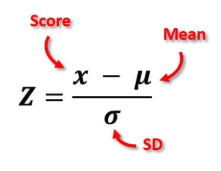


#### **2.1 Prepare Ashwood Baseline Data**

We create `ashwood_analysis_df` from `df_q3_model`, 

- sort trials in the correct order by `intervals_0`, 

- create `trial numbers` column within each session, 

- create the `bias` column, and 

- build the Ashwood history predictors: `prev_choice_centered`, `prev_reward_centered`, and `prev_choice_x_reward`

This gives us a clean dataframe with only the columns needed for the Ashwood-style GLM-HMM baseline analysis.


In [405]:
# Build clean Ashwood baseline dataset from df_q3_model.
# We keep first 90 trials with probabilityLeft == 0.5,
# create Ashwood predictors, filter good sessions, normalize stimulus,
# and choose mice for mouse-level GLM-HMM fitting.

model_sort_columns = ['subject', 'session', 'intervals_0']
model_time_sort_column = 'intervals_0'

ashwood_analysis_df = (df_q3_model.sort_values(model_sort_columns).copy(deep=True))

ashwood_analysis_df['ashwood_trial_number'] = (ashwood_analysis_df.groupby(['subject', 'session']).cumcount() + 1)

ashwood_analysis_df['bias'] = 1.0

ashwood_analysis_df['prev_choice_centered'] = (ashwood_analysis_df['prev_choice_binary'].astype(float) * 2 - 1)

ashwood_analysis_df['prev_reward_centered'] = (ashwood_analysis_df['prev_rewarded'].astype(float) * 2 - 1)

ashwood_analysis_df['prev_choice_x_reward'] = (ashwood_analysis_df['prev_choice_centered'] * ashwood_analysis_df['prev_reward_centered'])

needed_cols = [
    'subject',
    'session',
    'intervals_0',
    'ashwood_trial_number',
    'probabilityLeft',
    'choice',
    'choice_binary',
    'signed_contrast',
    'bias',
    'prev_choice_binary',
    'prev_rewarded',
    'prev_choice_centered',
    'prev_reward_centered',
    'prev_choice_x_reward'
]


ashwood_analysis_df = ashwood_analysis_df[needed_cols].copy(deep=True)

display(ashwood_analysis_df.head(1))

,subject,session,intervals_0,ashwood_trial_number,probabilityLeft,choice,choice_binary,signed_contrast,bias,prev_choice_binary,prev_rewarded,prev_choice_centered,prev_reward_centered,prev_choice_x_reward
55856,CSHL045,034e726f-b35f-41e0-8d6c-a22cc32391fb,27.458533,1,0.5,1.0,1,-0.125,1.0,1,1,1.0,1.0,1.0


#### **2.2 Filter Baseline Trials And Sessions**

1. we apply a **`trial-level filter`**.  

This keeps only trials that match the `Ashwood` baseline condition:

```text
- first 90 trials
- probabilityLeft == 0.5
- valid binary choice
- no missing model inputs
```

2. we apply a **`session-level filter`**.  

Even if some trials are valid, the whole session may still be too noisy or incomplete, so we keep only sessions with:

```text
- enough valid trials
- not too many violation trials
- confirmed 50/50 probability
```

This gives us clean `first-90` unbiased sessions for the mouse-level GLM-HMM fit.

#### **2.3 Apply Trial-Level Baseline Filter**

We first filter individual trials to match the Ashwood baseline condition.

We keep only trials that are:

- within the first 90 trials of the session

- in the 50/50 unbiased condition (`probabilityLeft == 0.5`)

- valid binary-choice trials

- not missing any model inputs

This creates `baseline_df`, which contains clean baseline trials before applying any session-level filtering.

In [406]:
# Select Ashwood baseline trials, keep good sessions, normalize stimulus,
# and choose mice for mouse-level GLM-HMM fitting.
# Define the Ashwood baseline rule.
# We keep trials within the first 90 trials of the session
# and in the 50/50 unbiased condition, where probabilityLeft == 0.5.

baseline_source = 'ashwood_trial_number <= 90 and probabilityLeft == 0.5'

# Select baseline candidate trials.
# .copy() makes a separate dataframe so later edits do not affect ashwood_analysis_df.
baseline_candidate_df = ashwood_analysis_df[
    (ashwood_analysis_df['ashwood_trial_number'] <= 90)
    & ((ashwood_analysis_df['probabilityLeft'] - 0.5).abs() <= TASK_PROBABILITY_LEFT_TOLERANCE)
].copy()

# Mark violation-like trials.
# In IBL raw choice, choice == 0 means no valid left/right response.
# We mark these trials so we can later exclude bad sessions.
baseline_candidate_df['ashwood_violation_like'] = (
    baseline_candidate_df['choice'].eq(0)
)

# Keep only valid binary-choice trials. GLM-HMM needs choices coded as 0 or 1.
# This removes trials with invalid choice labels.

baseline_df = baseline_candidate_df[
    baseline_candidate_df['choice_binary'].isin([0, 1])
].copy()

baseline_df['choice_binary'] = baseline_df['choice_binary'].astype(int)

# Remove trials with missing model inputs.
# These columns are required for fitting the Ashwood-style GLM-HMM.
# Rows missing any of them cannot be used.

baseline_df = baseline_df.dropna(
    subset=[
        'subject',
        'session',
        'choice_binary',
        'intervals_0',
        'prev_choice_centered',
        'prev_choice_x_reward',
        'bias',
        'signed_contrast'
    ]
).copy()

# Display cleaned trial-level baseline data.

display(baseline_df.head(1))

,subject,session,intervals_0,ashwood_trial_number,probabilityLeft,choice,choice_binary,signed_contrast,bias,prev_choice_binary,prev_rewarded,prev_choice_centered,prev_reward_centered,prev_choice_x_reward,ashwood_violation_like
55856,CSHL045,034e726f-b35f-41e0-8d6c-a22cc32391fb,27.458533,1,0.5,1.0,1,-0.125,1.0,1,1,1.0,1.0,1.0,False


#### **2.4 Apply Session-Level Filter**

After the trial-level filter, we check whether each session is good enough to use.

For each `subject` and `session`, we calculate:

- number of valid trials

- number of violation-like trials

- whether `probabilityLeft` is still close to `0.5`

- whether left/right stimuli are reasonably balanced

Then we keep only sessions that have enough valid trials, few violations, and confirmed 50/50 probability.

This creates:

- `baseline_session_check_df` = summary table for checking each session

- `eligible_sessions_df` = sessions that pass the session-level filter

- `baseline_eligible_df` = clean trials from eligible sessions only

In [407]:
# Session-level filter:
# Check each session and keep only sessions with enough trials,
# few violations, and confirmed 50/50 probability.


# Create a session summary from baseline candidate trials.
# For each mouse/session, count candidate trials, violation-like trials,
# and average probabilityLeft.
# This checks whether the session belongs to the 50/50 baseline period.

baseline_session_check_df = (
    baseline_candidate_df
    .groupby(['subject', 'session'], as_index=False)
    .agg(
        n_candidate_trials=('choice_binary', 'size'),
        n_violations_50=('ashwood_violation_like', 'sum'),
        mean_probability_left=('probabilityLeft', 'mean')
    )
)

# Count valid trials and stimulus sides for each session.
# This checks whether the session has enough usable data and whether left/right stimuli are roughly balanced.
valid_session_counts_df = (
    baseline_df
    .groupby(['subject', 'session'], as_index=False)
    .agg(
        n_trials=('choice_binary', 'size'),
        n_right_stimulus=('signed_contrast', lambda x: (x > 0).sum()),
        n_left_stimulus=('signed_contrast', lambda x: (x < 0).sum())
    )
)

# Combine all session-level checks into one table. If a session has no valid trials after filtering, fill counts with 0.

baseline_session_check_df = (
    baseline_session_check_df
    .merge(valid_session_counts_df, on=['subject', 'session'], how='left')
    .fillna({
        'n_trials': 0,
        'n_right_stimulus': 0,
        'n_left_stimulus': 0
    })
)

baseline_session_check_df[['n_trials', 'n_right_stimulus', 'n_left_stimulus']] = (
    baseline_session_check_df[['n_trials', 'n_right_stimulus', 'n_left_stimulus']]
    .astype(int)
)

# Check left/right stimulus balance.
# Total nonzero stimulus trials = right stimulus trials + left stimulus trials.
# Then calculate the fraction of right-side stimuli.

baseline_session_check_df['n_nonzero_stimulus_trials'] = (
    baseline_session_check_df['n_right_stimulus'] + baseline_session_check_df['n_left_stimulus']
)
baseline_session_check_df['fraction_right_stimulus'] = (
    baseline_session_check_df['n_right_stimulus'] / baseline_session_check_df['n_nonzero_stimulus_trials'].replace(0, np.nan)
)
baseline_session_check_df['balanced_left_right'] = (
    (baseline_session_check_df['fraction_right_stimulus'] - 0.5).abs() <= TASK_BALANCE_TOLERANCE
)

# Check that probabilityLeft is 0.5.
# This confirms the session is in the unbiased 50/50 condition.

baseline_session_check_df['probability_left_05'] = (
    (baseline_session_check_df['mean_probability_left'] - 0.5).abs() <= TASK_PROBABILITY_LEFT_TOLERANCE
)

# Keep only eligible sessions.
# A session is kept if it has enough valid trials, not too many violation-like trials, and confirmed probabilityLeft == 0.5.

eligible_sessions_df = baseline_session_check_df[
    (baseline_session_check_df['n_trials'] >= TASK_MIN_SESSION_TRIALS)
    & (baseline_session_check_df['n_violations_50'] <= TASK_MAX_VIOLATIONS_50)
    & (baseline_session_check_df['probability_left_05'])
].copy()

# Keep only trials from eligible sessions.
# This creates the final session-cleaned baseline dataset.

baseline_eligible_df = baseline_df.merge(
    eligible_sessions_df[['subject', 'session']],
    on=['subject', 'session'],
    how='inner'
).copy()

#### **2.5 Normalize Stimulus**

After the session-level filter, we normalize `signed_contrast`.

This creates a new column called `ashwood_stimulus`.

```text
ashwood_stimulus = (signed_contrast - mean) / standard deviation
```
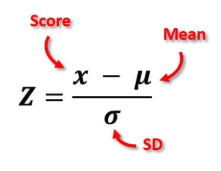

In [408]:
stimulus_mean = baseline_eligible_df['signed_contrast'].mean()
stimulus_std = baseline_eligible_df['signed_contrast'].std(ddof=0)

if not np.isfinite(stimulus_std) or stimulus_std == 0:
    stimulus_std = 1.0

baseline_eligible_df['ashwood_stimulus'] = (
    (baseline_eligible_df['signed_contrast'] - stimulus_mean) / stimulus_std
    if TASK_NORMALIZE_STIMULUS
    else baseline_eligible_df['signed_contrast']
)

#### **2.6 Define GLM-HMM Input Columns**

These are the columns that will be passed into the `Ashwood-style GLM-HMM`.

In [409]:
ashwood_model_input_columns = [
    'ashwood_stimulus',
    'prev_choice_centered',
    'prev_choice_x_reward',
    'bias'
]

ashwood_state_weight_labels = {
    'stimulus': 'ashwood_stimulus_weight',
    'previous_choice': 'prev_choice_centered_weight',
    'wsls': 'prev_choice_x_reward_weight',
    'bias': 'bias_weight'
}

#### **2.7 Summarize Each Mouse**

At this point, we already have clean baseline trials from `good sessions`.

Now we `summarize` the data for each mouse.  

We need this because Ashwood fits **`one model per mouse`**, so each mouse must have enough trials and sessions.

In [410]:
# Create one summary row per mouse.
# This tells us how much clean baseline data each mouse has.

mouse_baseline_check_df = (
    baseline_eligible_df
    .groupby('subject', as_index=False)
    .agg(
        # Number of sessions available for this mouse
        n_sessions=('session', 'nunique'),

        # Number of clean baseline trials available for this mouse
        n_trials=('choice_binary', 'size'),

        # Number of trials where stimulus was on the right side
        n_right_stimulus=('signed_contrast', lambda x: (x > 0).sum()),

        # Number of trials where stimulus was not zero contrast
        n_nonzero_stimulus=('signed_contrast', lambda x: (x != 0).sum())
    )
)

# Calculate the fraction of nonzero stimulus trials that were right-side stimuli.
# This checks whether the mouse-level baseline data is roughly balanced.

mouse_baseline_check_df['fraction_right_stimulus'] = (
    mouse_baseline_check_df['n_right_stimulus']
    / mouse_baseline_check_df['n_nonzero_stimulus'].replace(0, np.nan)
)

display(mouse_baseline_check_df.head())

,subject,n_sessions,n_trials,n_right_stimulus,n_nonzero_stimulus,fraction_right_stimulus
0,CSHL045,20,1780,685,1451,0.472088
1,CSHL046,18,1602,637,1294,0.492272
2,CSHL047,21,1864,777,1521,0.510848
3,CSHL049,20,1780,731,1455,0.502405
4,CSHL051,23,2039,829,1649,0.502729


#### **2.8 Select Mice For `GLM-HMM` Fitting**

Now we choose which mice have enough data for the `Ashwood-style mouse-level GLM-HMM`.

We first try the strict Ashwood-style rule.  

If no mice pass that rule, we use a relaxed fallback rule so the notebook can still run on the local dataset.

In [411]:
# Check which mice satisfy the strict Ashwood-style rule.
# Strict rule = enough sessions and enough total trials.
mouse_baseline_check_df['strict_ashwood_eligible_mouse'] = (
    (mouse_baseline_check_df['n_sessions'] >= TASK_STRICT_MIN_SESSIONS_PER_MOUSE)
    & (mouse_baseline_check_df['n_trials'] >= TASK_MIN_TRIALS_PER_MOUSE)
)

# Check which mice satisfy the relaxed fallback rule.
# This is useful when the local dataset has fewer sessions than the full Ashwood dataset.
mouse_baseline_check_df['available_data_eligible_mouse'] = (
    (mouse_baseline_check_df['n_sessions'] >= TASK_RELAXED_MIN_SESSIONS_PER_MOUSE)
    & (mouse_baseline_check_df['n_trials'] >= TASK_MIN_TRIALS_PER_MOUSE)
)

# Prefer strict Ashwood-style mice.
# If at least one mouse passes the strict rule, use those mice.
if mouse_baseline_check_df['strict_ashwood_eligible_mouse'].any():
    selected_session_rule = (
        f'strict Ashwood-style >= {TASK_STRICT_MIN_SESSIONS_PER_MOUSE} sessions'
    )
    selected_mouse_mask = mouse_baseline_check_df['strict_ashwood_eligible_mouse']

# If no mouse passes the strict rule, use the relaxed fallback rule.
else:
    selected_session_rule = (
        f'available-data fallback >= {TASK_RELAXED_MIN_SESSIONS_PER_MOUSE} sessions'
    )
    selected_mouse_mask = mouse_baseline_check_df['available_data_eligible_mouse']

# Get the subject IDs of mice selected for model fitting.
eligible_mice = mouse_baseline_check_df.loc[
    selected_mouse_mask,
    'subject'
].tolist()

# Optionally limit the number of mice for a faster run.
if TASK_MAX_MICE is not None:
    eligible_mice = eligible_mice[:TASK_MAX_MICE]


# Store selection information in the mouse summary table.
mouse_baseline_check_df['selected_for_fit'] = (
    mouse_baseline_check_df['subject'].isin(eligible_mice)
)
mouse_baseline_check_df['selection_rule'] = selected_session_rule
mouse_baseline_check_df['stimulus_zscore_mean'] = stimulus_mean
mouse_baseline_check_df['stimulus_zscore_std'] = stimulus_std


# Save the final mouse-level baseline check table.
taskB_baseline_check_df = mouse_baseline_check_df.copy()

# Print a short summary so we can check the dataset.
print('Baseline source:', baseline_source)
print('Baseline candidate rows:', len(baseline_candidate_df))
print('Eligible baseline sessions:', len(eligible_sessions_df))
print('Selected mice:', len(eligible_mice), '| rule:', selected_session_rule)
print('Model input columns:', ashwood_model_input_columns)

display(taskB_baseline_check_df.head())

Baseline source: ashwood_trial_number <= 90 and probabilityLeft == 0.5
Baseline candidate rows: 258936
Eligible baseline sessions: 2867
Selected mice: 10 | rule: strict Ashwood-style >= 30 sessions
Model input columns: ['ashwood_stimulus', 'prev_choice_centered', 'prev_choice_x_reward', 'bias']


,subject,n_sessions,n_trials,n_right_stimulus,n_nonzero_stimulus,fraction_right_stimulus,strict_ashwood_eligible_mouse,available_data_eligible_mouse,selected_for_fit,selection_rule,stimulus_zscore_mean,stimulus_zscore_std
0,CSHL045,20,1780,685,1451,0.472088,False,True,False,strict Ashwood-style >= 30 sessions,-0.000425,0.474063
1,CSHL046,18,1602,637,1294,0.492272,False,True,False,strict Ashwood-style >= 30 sessions,-0.000425,0.474063
2,CSHL047,21,1864,777,1521,0.510848,False,True,False,strict Ashwood-style >= 30 sessions,-0.000425,0.474063
3,CSHL049,20,1780,731,1455,0.502405,False,True,False,strict Ashwood-style >= 30 sessions,-0.000425,0.474063
4,CSHL051,23,2039,829,1649,0.502729,False,True,False,strict Ashwood-style >= 30 sessions,-0.000425,0.474063


## 3. Load Mouse-Level Helper Functions

The helper functions now live in `ssm_new_full/ashwood_mouse_level.py`.

Here we only import them and pass the notebook settings into one config object.


#### **3.1 Import Helper Module And Create Config**

This keeps the notebook short: Section 4 will call these functions instead of defining them again.


In [412]:
# Import Ashwood mouse-level helper functions from the local ssm_new_full package.
from ssm_new_full.ashwood_mouse_level import (
    AshwoodFitConfig,
    compare_models_for_mouse,
    decode_mouse_trials,
    fit_final_three_state_model,
    prepare_mouse_for_fit,
    summarize_mouse_fit,
)

# Store the notebook settings that the helper functions need.
ashwood_fit_config = AshwoodFitConfig(
    input_columns=ashwood_model_input_columns,
    time_sort_column=model_time_sort_column,
    state_weight_labels=ashwood_state_weight_labels,
    stim_weight_col=ashwood_state_weight_labels['stimulus'],
    bias_weight_col=ashwood_state_weight_labels['bias'],
    num_folds=TASK_NUM_FOLDS,
    model_k_list=TASK_MODEL_K_LIST,
    hmm_max_iter=TASK_HMM_MAX_ITER,
    hmm_n_restarts=TASK_HMM_N_RESTARTS,
    stay_probability=TASK_STAY_PROBABILITY,
    prior_sigma=TASK_PRIOR_SIGMA,
    engaged_contrast_min=TASK_ENGAGED_CONTRAST_MIN,
    bias_sign_min=TASK_BIAS_SIGN_MIN,
)

print('Loaded helper module: ssm_new_full.ashwood_mouse_level')


Loaded helper module: ssm_new_full.ashwood_mouse_level


## 4. Fit and Evaluate Mouse-Level Ashwood GLM-HMM Models

Now we fit the actual models.

The goal is simple:

```text
for each mouse
    use all clean 50/50 baseline sessions
    compare 1-state GLM vs GLM-HMM
    fit final 3-state GLM-HMM
    decode hidden states
    summarize states, accuracy, switching, and dwell time
```


#### **4.1 Prepare Containers For Results**

We create empty lists that will store results for every mouse.

Each list becomes one output table later.


In [413]:
# Store results from each mouse before turning them into final tables.
fit_rows = []
comparison_fold_rows = []
state_rows = []
state_weight_rows = []
accuracy_rows = []
occupancy_rows = []
switch_rows = []
dwell_rows = []
decoded_parts = []
mouse_fit_details = {}


#### **4.2 Run Imported Helper Functions For Each Mouse**

The helper functions were imported from `ssm_new_full/ashwood_mouse_level.py`.

This loop is where the analysis actually runs:

```text
for each selected mouse
    prepare ordered baseline sessions
    compare 1-state GLM vs GLM-HMM
    fit final 3-state GLM-HMM
    decode hidden states
    summarize accuracy, occupancy, switching, and dwell time
```


In [414]:
for mouse_idx, subject in enumerate(eligible_mice):
    mouse_df, sessions, n_sessions, n_trials, fold_lookup = prepare_mouse_for_fit(
        subject,
        mouse_idx,
        baseline_eligible_df,
        ashwood_fit_config,
    )
    fit_status = 'ok'

    try:
        # Compare model performance using held-out sessions.
        comparison_fold_rows.extend(
            compare_models_for_mouse(
                subject,
                mouse_idx,
                mouse_df,
                fold_lookup,
                ashwood_fit_config,
            )
        )

        # Fit the final 3-state model and decode trial-by-trial hidden states.
        final_fit = fit_final_three_state_model(
            mouse_idx,
            mouse_df,
            sessions,
            ashwood_fit_config,
        )
        decoded_mouse_df = decode_mouse_trials(final_fit)
        decoded_parts.append(decoded_mouse_df.assign(subject=subject))

        # Convert decoded states into summary rows and tables.
        state_row, state_weight_df, accuracy_row, occupancy_row, switch_row, dwell_row = summarize_mouse_fit(
            subject,
            final_fit,
            decoded_mouse_df,
            ashwood_fit_config,
        )
        state_rows.append(state_row)
        state_weight_rows.append(state_weight_df)
        accuracy_rows.append(accuracy_row)
        occupancy_rows.append(occupancy_row)
        switch_rows.append(switch_row)
        dwell_rows.append(dwell_row)

        mouse_fit_details[subject] = {
            'model3': final_fit['model3'],
            'state_params_df': final_fit['params3'],
            'transition_matrix': final_fit['transition'],
            'decoded_df': decoded_mouse_df,
            'fold_lookup': fold_lookup,
        }

    except Exception as exc:
        fit_status = f'failed: {exc}'

    # Record whether this mouse fit succeeded or failed.
    fit_rows.append({
        'subject': subject,
        'n_sessions': n_sessions,
        'n_trials': n_trials,
        'fit_status': fit_status,
        'selection_rule': selected_session_rule,
    })


#### **4.3 Build The Final Task Tables**

After all mice are processed, we convert the stored rows into pandas tables.

This section is split by output group so it is easier to read and rerun.


##### **4.3.1 Task A: Mouse Fit Status**

This table shows which mice were fit successfully and how much data each mouse had.


In [415]:
# Build the mouse-level fit status table.
taskA_mouse_fit_df = pd.DataFrame(fit_rows)

display(taskA_mouse_fit_df.head())


,subject,n_sessions,n_trials,fit_status,selection_rule
0,CSHL_003,56,4965,ok,strict Ashwood-style >= 30 sessions
1,CSHL_005,50,4451,ok,strict Ashwood-style >= 30 sessions
2,CSHL_008,56,4984,ok,strict Ashwood-style >= 30 sessions
3,CSHL_014,57,5072,ok,strict Ashwood-style >= 30 sessions
4,CSHL_015,42,3738,ok,strict Ashwood-style >= 30 sessions


##### **4.3.2 Task C: Model Comparison**

This table compares the 1-state GLM with the GLM-HMM models using held-out sessions.


In [416]:
# Build the fold-level and mouse-level model comparison tables.
taskC_model_comparison_by_fold_df = pd.DataFrame(comparison_fold_rows)

if not taskC_model_comparison_by_fold_df.empty:
    taskC_model_comparison_df = (
        taskC_model_comparison_by_fold_df
        .groupby(['subject', 'model', 'n_states'], as_index=False)
        .agg(
            test_log_likelihood_per_trial=('test_log_likelihood_per_trial', 'mean'),
            test_accuracy=('test_accuracy', 'mean'),
            n_folds=('fold', 'nunique'),
        )
    )
else:
    taskC_model_comparison_df = pd.DataFrame()

display(taskC_model_comparison_df.head())


,subject,model,n_states,test_log_likelihood_per_trial,test_accuracy,n_folds
0,CSHL_003,1-state GLM,1,-0.434459,0.820538,2
1,CSHL_003,3-state GLM-HMM,3,-0.378044,0.845077,2
2,CSHL_005,1-state GLM,1,-0.479157,0.777349,2
3,CSHL_005,3-state GLM-HMM,3,-0.356534,0.876655,2
4,CSHL_008,1-state GLM,1,-0.485876,0.761437,2


##### **4.3.3 Tasks D-H: State Summary Tables**

These tables summarize state interpretation, accuracy, occupancy, switching, and dwell time.


In [417]:
# Build the Ashwood state summary tables.
taskD_state_interpretation_df = pd.DataFrame(state_rows)
ashwood_state_weight_table_df = (
    pd.concat(state_weight_rows, ignore_index=True)
    if state_weight_rows
    else pd.DataFrame()
)
taskE_accuracy_by_state_df = pd.DataFrame(accuracy_rows)
taskF_state_occupancy_df = pd.DataFrame(occupancy_rows)
taskG_state_switching_df = pd.DataFrame(switch_rows)
taskH_dwell_self_transition_df = pd.DataFrame(dwell_rows)
mouse_decoded_baseline_df = (
    pd.concat(decoded_parts, ignore_index=True)
    if decoded_parts
    else pd.DataFrame()
)


## 5. Tasks D-H: Mouse-Level Ashwood Summary Tables

This section displays the main per-mouse Ashwood-style state tables.


#### **5.1 State Weight Table**

This table shows the fitted GLM weights for each hidden state.


In [418]:
# Show the fitted GLM weights for each state and mouse.
display(ashwood_state_weight_table_df.head(10))


,subject,state,suggested_label,strongest_weight,strongest_weight_value,signed_contrast_weight,bias_weight,prev_choice_centered_weight,prev_choice_x_reward_weight
0,CSHL_003,0,stimulus-sensitive / engaged,signed_contrast,10.201448,10.201448,0.192229,0.201641,-0.072758
1,CSHL_003,1,left-biased / disengaged,signed_contrast,1.613428,1.613428,-1.051860,0.238990,0.143949
2,CSHL_003,2,right-biased / disengaged,signed_contrast,1.872714,1.872714,1.651595,0.289693,0.229501
3,CSHL_005,0,stimulus-sensitive / engaged,signed_contrast,6.449971,6.449971,1.028309,0.526089,-0.033510
4,CSHL_005,1,left-biased / disengaged,signed_contrast,5.024744,5.024744,-1.813857,-0.102119,0.804151
5,CSHL_005,2,right-biased / disengaged,prev_choice_centered,3.367098,0.659872,-1.066531,3.367098,0.152220
6,CSHL_008,0,stimulus-sensitive / engaged,signed_contrast,6.532704,6.532704,-0.812198,0.140090,0.098442
7,CSHL_008,1,right-biased / disengaged,signed_contrast,5.334273,5.334273,0.993826,-0.216326,0.262183
8,CSHL_008,2,left-biased / disengaged,prev_choice_centered,1.769439,0.918734,-0.093329,1.769439,-0.006064
9,CSHL_014,0,right-biased / disengaged,bias,2.793416,1.062651,2.793416,-0.084524,0.513595


#### **5.2 Task D: State Interpretation**

This table checks whether each mouse has engaged, left-biased, and right-biased states.


In [419]:
# Show the Ashwood-style state labels for each mouse.
display(taskD_state_interpretation_df.head())


,subject,engaged_state,left_biased_state,right_biased_state,engaged_state_found,left_biased_state_found,right_biased_state_found,ashwood_state_order_complete,all_3_state_types_found,max_stimulus_weight,min_bias_weight,max_bias_weight,engaged_bias_weight,left_biased_bias_weight,right_biased_bias_weight
0,CSHL_003,0,1,2,True,True,True,True,True,10.201448,-1.051860,1.651595,0.192229,-1.051860,1.651595
1,CSHL_005,0,1,2,True,True,False,True,False,6.449971,-1.813857,1.028309,1.028309,-1.813857,-1.066531
2,CSHL_008,0,2,1,True,True,True,True,True,6.532704,-0.812198,0.993826,-0.812198,-0.093329,0.993826
3,CSHL_014,2,1,0,True,True,True,True,True,5.972695,-0.958620,2.793416,-0.441851,-0.958620,2.793416
4,CSHL_015,0,1,2,True,True,True,True,True,6.195967,-2.336774,2.253102,-0.206523,-2.336774,2.253102


#### **5.3 Task E: Accuracy By State**

This table compares accuracy during engaged and biased states.


In [420]:
# Show stimulus accuracy separately for each decoded state type.
display(taskE_accuracy_by_state_df.head())


,subject,accuracy_engaged,accuracy_left_biased,accuracy_right_biased,overall_accuracy
0,CSHL_003,0.926391,0.693423,0.697228,0.853037
1,CSHL_005,0.833751,0.790850,0.566543,0.736216
2,CSHL_008,0.857418,0.610478,0.840056,0.802368
3,CSHL_014,0.850201,0.608696,0.613487,0.757732
4,CSHL_015,0.855342,0.693305,0.605479,0.770046


#### **5.4 Task F: State Occupancy**

This table shows the fraction of trials spent in each state type.


In [421]:
# Show how often each mouse occupies each state type.
display(taskF_state_occupancy_df.head())


,subject,engaged_fraction,left_biased_fraction,right_biased_fraction
0,CSHL_003,0.669084,0.218530,0.112387
1,CSHL_005,0.503033,0.153224,0.343743
2,CSHL_008,0.471910,0.202047,0.326043
3,CSHL_014,0.614945,0.089511,0.295544
4,CSHL_015,0.603799,0.152755,0.243446


#### **5.5 Task G: State Switching Within Sessions**

This table checks whether states switch within sessions instead of staying fixed for a whole session.


In [422]:
# Show how often decoded states switch within sessions.
display(taskG_state_switching_df.head())


,subject,fraction_sessions_with_any_switch,fraction_sessions_with_multiple_switches,median_switches_per_session
0,CSHL_003,0.500000,0.339286,0.5
1,CSHL_005,0.720000,0.540000,2.0
2,CSHL_008,0.517857,0.250000,1.0
3,CSHL_014,0.736842,0.561404,2.0
4,CSHL_015,0.809524,0.690476,2.0


#### **5.6 Task H: Dwell Time And Self-Transition**

This table measures how persistent the hidden states are across trials.


In [423]:
# Show self-transition probability and expected dwell time for each state type.
display(taskH_dwell_self_transition_df.head())


,subject,mean_self_transition_probability,expected_dwell_time_engaged,expected_dwell_time_left_biased,expected_dwell_time_right_biased
0,CSHL_003,0.954364,92.633978,21.401723,12.596245
1,CSHL_005,0.939623,28.661946,9.826714,22.483645
2,CSHL_008,0.959499,40.146792,19.592351,21.952427
3,CSHL_014,0.941699,27.541565,11.723500,18.763410
4,CSHL_015,0.938798,21.642754,16.531001,13.002373


#### **5.7 Combined Mouse-Level Summary**

This merges the Task A-H outputs into one table for easier interpretation.


In [424]:
# Merge all per-mouse summary tables into one final mouse-level table.
ashwood_mouse_level_summary_df = (
    taskA_mouse_fit_df
    .merge(taskB_baseline_check_df[['subject', 'fraction_right_stimulus']], on='subject', how='left')
    .merge(taskD_state_interpretation_df, on='subject', how='left')
    .merge(taskE_accuracy_by_state_df, on='subject', how='left')
    .merge(taskF_state_occupancy_df, on='subject', how='left')
    .merge(taskG_state_switching_df, on='subject', how='left')
    .merge(taskH_dwell_self_transition_df, on='subject', how='left')
)

display(ashwood_mouse_level_summary_df.head())


,subject,n_sessions,n_trials,fit_status,selection_rule,fraction_right_stimulus,engaged_state,left_biased_state,right_biased_state,engaged_state_found,...,engaged_fraction,left_biased_fraction,right_biased_fraction,fraction_sessions_with_any_switch,fraction_sessions_with_multiple_switches,median_switches_per_session,mean_self_transition_probability,expected_dwell_time_engaged,expected_dwell_time_left_biased,expected_dwell_time_right_biased
0,CSHL_003,56,4965,ok,strict Ashwood-style >= 30 sessions,0.498841,0,1,2,True,...,0.669084,0.218530,0.112387,0.500000,0.339286,0.5,0.954364,92.633978,21.401723,12.596245
1,CSHL_005,50,4451,ok,strict Ashwood-style >= 30 sessions,0.488619,0,1,2,True,...,0.503033,0.153224,0.343743,0.720000,0.540000,2.0,0.939623,28.661946,9.826714,22.483645
2,CSHL_008,56,4984,ok,strict Ashwood-style >= 30 sessions,0.498179,0,2,1,True,...,0.471910,0.202047,0.326043,0.517857,0.250000,1.0,0.959499,40.146792,19.592351,21.952427
3,CSHL_014,57,5072,ok,strict Ashwood-style >= 30 sessions,0.499018,2,1,0,True,...,0.614945,0.089511,0.295544,0.736842,0.561404,2.0,0.941699,27.541565,11.723500,18.763410
4,CSHL_015,42,3738,ok,strict Ashwood-style >= 30 sessions,0.496024,0,1,2,True,...,0.603799,0.152755,0.243446,0.809524,0.690476,2.0,0.938798,21.642754,16.531001,13.002373


## 6. Task I: Population Summary Across Mice


In [425]:
# Summarize the results across mice and check whether engaged-state accuracy is higher than biased-state accuracy.

valid_summary = ashwood_mouse_level_summary_df[ashwood_mouse_level_summary_df['fit_status'] == 'ok'].copy()

population_summary = {
    'number_of_mice': len(valid_summary),
    'mice_with_complete_ashwood_state_order': int(valid_summary['ashwood_state_order_complete'].fillna(False).sum()) if not valid_summary.empty else 0,
    'mice_showing_all_3_state_types': int(valid_summary['all_3_state_types_found'].fillna(False).sum()) if not valid_summary.empty else 0,
    'mean_engaged_fraction': valid_summary['engaged_fraction'].mean() if not valid_summary.empty else np.nan,
    'median_engaged_fraction': valid_summary['engaged_fraction'].median() if not valid_summary.empty else np.nan,
    'mean_accuracy_engaged': valid_summary['accuracy_engaged'].mean() if not valid_summary.empty else np.nan,
    'median_accuracy_engaged': valid_summary['accuracy_engaged'].median() if not valid_summary.empty else np.nan,
    'mean_accuracy_left_biased': valid_summary['accuracy_left_biased'].mean() if not valid_summary.empty else np.nan,
    'median_accuracy_left_biased': valid_summary['accuracy_left_biased'].median() if not valid_summary.empty else np.nan,
    'mean_accuracy_right_biased': valid_summary['accuracy_right_biased'].mean() if not valid_summary.empty else np.nan,
    'median_accuracy_right_biased': valid_summary['accuracy_right_biased'].median() if not valid_summary.empty else np.nan,
    'mean_median_switches_per_session': valid_summary['median_switches_per_session'].mean() if not valid_summary.empty else np.nan,
    'median_median_switches_per_session': valid_summary['median_switches_per_session'].median() if not valid_summary.empty else np.nan,
    'mean_self_transition_probability': valid_summary['mean_self_transition_probability'].mean() if not valid_summary.empty else np.nan,
}

taskI_population_summary_df = pd.DataFrame([population_summary])
display(taskI_population_summary_df)

if not valid_summary.empty:
    engaged_better_than_biased = (
        valid_summary['accuracy_engaged']
        > valid_summary[['accuracy_left_biased', 'accuracy_right_biased']].mean(axis=1)
    )
    print('Mice where engaged accuracy > mean biased-state accuracy:', int(engaged_better_than_biased.sum()), '/', len(valid_summary))


,number_of_mice,mice_with_complete_ashwood_state_order,mice_showing_all_3_state_types,mean_engaged_fraction,median_engaged_fraction,mean_accuracy_engaged,median_accuracy_engaged,mean_accuracy_left_biased,median_accuracy_left_biased,mean_accuracy_right_biased,median_accuracy_right_biased,mean_median_switches_per_session,median_median_switches_per_session,mean_self_transition_probability
0,10,10,8,0.569361,0.600742,0.875018,0.874671,0.700134,0.693364,0.672502,0.611379,1.15,1.0,0.952587


Mice where engaged accuracy > mean biased-state accuracy: 10 / 10
